In [578]:
import numpy as np # For numerical operations, especially NaN
import pandas as pd # For data manipulation and analysis

In [579]:
df_unclean=pd.read_csv("/content/marketing_campaign_data_messy.csv") # Load the dataset from the specified CSV file into a pandas DataFrame.
print(f"Loaded Dataset has:\n{df_unclean.shape[0]} Rows  \n{df_unclean.shape[1]} Columns") # Print the number of rows and columns in the loaded DataFrame.

Loaded Dataset has:
2020 Rows  
12 Columns


In [580]:
display(df_unclean.head()) # Display the first 5 rows of the DataFrame

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [581]:
display(df_unclean.describe()) # Display descriptive statistics of the DataFrame

,Impressions,Clicks,Conversions,Clicks
count,2020.000000,2020.000000,1820.000000,40.000000
mean,49839.896040,1500.744059,186.085714,54856.200000
std,28579.637473,1084.765654,160.129172,30552.773369
min,1055.000000,11.000000,0.000000,2508.000000
25%,25033.500000,650.750000,68.000000,30164.750000
50%,50097.500000,1245.000000,142.000000,57707.500000
75%,74784.250000,2185.250000,257.000000,81497.500000
max,99875.000000,4812.000000,943.000000,99483.000000


In [582]:
display(df_unclean.info()) # Display a concise summary of the DataFrame, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2020 non-null   object 
 1   Campaign_Name  2020 non-null   object 
 2   Start_Date     2020 non-null   object 
 3   End_Date       2020 non-null   object 
 4   Channel        1919 non-null   object 
 5   Impressions    2020 non-null   int64  
 6   Clicks         2020 non-null   int64  
 7   Spend          2020 non-null   object 
 8   Conversions    1820 non-null   float64
 9   Active         2020 non-null   object 
 10  Clicks         40 non-null     float64
 11  Campaign_Tag   2020 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 189.5+ KB


None

In [583]:
# Step1: Cleaning Header
df_unclean.columns=df_unclean.columns.str.strip().str.replace(" ","_") # Strip whitespace from column names and replace spaces with underscores for easier access.
print(df_unclean.columns.tolist()) # Print the cleaned column names.
print("Step1: Header Cleaned Successfully") # Confirm the header cleaning operation.

['Campaign_ID', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel', 'Impressions', 'Clicks', 'Spend', 'Conversions', 'Active', 'Clicks', 'Campaign_Tag']
Step1: Header Cleaned Successfully


In [584]:
# Step2: Formatting Spend column to same type
# The .loc accessor works with boolean indexing here, as unclean_spend_type is a boolean Series used for row selection.
# Checks if the 'Spend' column contains values starting with a '$' symbol.
unclean_spend_type=df_unclean["Spend"].astype(str).str.contains(r'^\$')
print(unclean_spend_type.head())
# Display the head of the 'Spend' column for initial inspection.
display(df_unclean["Spend"].head())
# Displays the 'Spend' and 'Campaign_ID' for the first few campaigns where 'Spend' had a dollar sign.
print(df_unclean.loc[unclean_spend_type,['Spend','Campaign_ID']].head())

0     True
1    False
2    False
3    False
4    False
Name: Spend, dtype: bool


,Spend
0,$102.82
1,24.33
2,1323.39
3,2180.38
4,252.44


       Spend Campaign_ID
0    $102.82   CMP-00001
21   $2428.4   CMP-00022
22  $4726.22   CMP-00023
31  $2759.35   CMP-00032
32  $2393.02   CMP-00033


In [585]:
# Converts the 'Spend' column to string type and removes any character that is not a digit, a decimal point, or a minus sign.
df_unclean['Spend']=df_unclean['Spend'].astype(str).str.replace(r'[^\d.-]','',regex=True)
print(df_unclean[['Spend','Campaign_ID']].head()) # Display the first few rows of the cleaned 'Spend' column and 'Campaign_ID'.
# Converts the cleaned 'Spend' column to a numeric type, coercing errors to NaN.
df_unclean['Spend']=pd.to_numeric(df_unclean['Spend'],errors='coerce')
print("+"*30,"FIX APPLIED","+"*30) # Print a separator to indicate fix application.
print(df_unclean.loc[unclean_spend_type,['Spend','Campaign_ID']].head()) # Display the 'Spend' and 'Campaign_ID' for the first few campaigns where 'Spend' had a dollar sign after conversion.

     Spend Campaign_ID
0   102.82   CMP-00001
1    24.33   CMP-00002
2  1323.39   CMP-00003
3  2180.38   CMP-00004
4   252.44   CMP-00005
++++++++++++++++++++++++++++++ FIX APPLIED ++++++++++++++++++++++++++++++
      Spend Campaign_ID
0    102.82   CMP-00001
21  2428.40   CMP-00022
22  4726.22   CMP-00023
31  2759.35   CMP-00032
32  2393.02   CMP-00033


In [586]:
# Step3: Fixing Categorical Typos
print(df_unclean['Channel'].unique()) # Display unique values in the 'Channel' column before cleaning.
cleanup_map={
    'Facebok': 'Facebook',
    'Insta_gram': 'Instagram',
    'E-mail': 'Email',
    'Gogle': 'Google Ads',
    'Tik_Tok': 'TikTok',
    'Twitter': 'Twitter Ads',
    # Maps 'N/A' string values to NaN (Not a Number) for consistent handling of missing data.
    'N/A': np.nan
}
df_unclean['Channel']=df_unclean['Channel'].replace(cleanup_map) # Apply the cleanup map to correct typos and standardize channel names.
print("+"*30,"FIX APPLIED","+"*30) # Print a separator to indicate fix application.
print(df_unclean['Channel'].unique()) # Display unique values in the 'Channel' column after cleaning.

['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' 'E-mail' nan 'Gogle'
 'Tik_Tok' 'Facebok' 'Insta_gram']
++++++++++++++++++++++++++++++ FIX APPLIED ++++++++++++++++++++++++++++++
['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' nan]


In [587]:
df_unclean.groupby('Channel').size() # Group by 'Channel' and count the number of entries in each group.

,0
Channel,
Email,380
Facebook,405
Google Ads,360
Instagram,359
TikTok,415


In [588]:
#Step4: Handling Categorical 'Active' Column type to consistent datatype
print(df_unclean['Active'].unique()) # Display unique values in the 'Active' column before cleaning.
# Invert the mapping: map multiple input strings to a single boolean string representation
bool_map_fixed = {
    'Yes': 'True', '1': 'True', 'Y': 'True',
    'No': 'False', '0': 'False', 'N': 'False'
}
df_unclean['Active']=df_unclean['Active'].replace(bool_map_fixed) # Replace varied representations with standardized 'True'/'False' strings.
# Convert the column to actual boolean dtype for consistency by mapping 'True'/'False' strings to actual booleans
df_unclean['Active']=df_unclean['Active'].map({'True': True, 'False': False}) # Convert string 'True'/'False' to boolean True/False.
print("+"*30,"FIX APPLIED","+"*30) # Print a separator to indicate fix application.
print(df_unclean['Active'].unique()) # Display unique values in the 'Active' column after conversion to boolean type.

['Y' '0' 'No' 'True' 'Yes' '1' 'False']
++++++++++++++++++++++++++++++ FIX APPLIED ++++++++++++++++++++++++++++++
[ True False]


# Can Also use
- df_unclean['Active']=df_unclean['Active'].map(bool_map_fixed).fillna=False,astype(bool)
- # Convert the column to actual boolean dtype for consistency
- df_unclean['Active']=df_unclean['Active'].astype(bool)

In [589]:
# Step5: Date Parsing
print(df_unclean['Start_Date'])
df_unclean['Start_Date'] =pd.to_datetime(df_unclean['Start_Date'],errors='coerce')

print(df_unclean['Start_Date'])
print()
print()
print("New DataType for the Column 'Start_Date :",df_unclean['Start_Date'].dtype)

0       2023-11-24 00:00:00
1       2023-05-06 00:00:00
2       2023-12-13 00:00:00
3                2023-10-30
4       2023-04-22 00:00:00
               ...         
2015    2023-10-31 00:00:00
2016    2023-09-01 00:00:00
2017    2023-02-09 00:00:00
2018    2023-03-30 00:00:00
2019    2023-06-26 00:00:00
Name: Start_Date, Length: 2020, dtype: object
0      2023-11-24
1      2023-05-06
2      2023-12-13
3             NaT
4      2023-04-22
          ...    
2015   2023-10-31
2016   2023-09-01
2017   2023-02-09
2018   2023-03-30
2019   2023-06-26
Name: Start_Date, Length: 2020, dtype: datetime64[ns]


New DataType for the Column 'Start_Date : datetime64[ns]


In [590]:
""" Got the Error while running the below cell: Rectifying it
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
/tmp/ipykernel_406/4197676050.py in <cell line: 0>()
      1 #Step6: Logical Integrity (Clicks V/S Impressions)
----> 2 impossible_integrity_mask=df_unclean['Impressions']<df_unclean['Clicks']
      3 print(df_unclean.loc[impossible_integrity_mask,['Clicks','Impressions']].head())

3 frames
/usr/local/lib/python3.12/dist-packages/pandas/core/frame.py in _align_for_op(self, other, axis, flex, level)
   8203             if not flex:
   8204                 if not left.axes[axis].equals(right.index):
-> 8205                     raise ValueError(
   8206                         "Operands are not aligned. Do "
   8207                         "`left, right = left.align(right, axis=1, copy=False)` "

ValueError: Operands are not aligned. Do `left, right = left.align(right, axis=1, copy=False)` before operating.
"""
print(len(df_unclean.columns.tolist())) # Print the number of columns before fixing duplicates.
print()
print()
print('+'*30,'FIXED DUPLICATED COLUMNS','+'*30) # Print a separator to indicate fix application.
# This line removes duplicate columns from the DataFrame. Here's how it works:
# 1. `df_unclean.columns.duplicated()`: This part finds all column names that appear more than once. It returns a True/False list (boolean Series).
# 2. `~`: This symbol means 'NOT'. So, `~df_unclean.columns.duplicated()` creates a list of True/False values where 'True' means the column is NOT duplicated, and 'False' means it IS duplicated.
# 3. `df_unclean.loc[:, ...]` : This is used to select data. The `:` means 'select all rows'. The `~df_unclean.columns.duplicated()` in the column position means 'select only the columns that are NOT duplicated'.
# 4. `df_unclean = ...`: Finally, the DataFrame is updated to only include the columns that are unique.
df_unclean=df_unclean.loc[:, ~df_unclean.columns.duplicated()] # Remove duplicate columns from the DataFrame.
print(df_unclean.columns.tolist()) # Print the list of column names after removing duplicates.
print(len(df_unclean.columns.tolist())) # Print the number of columns after removing duplicates.

12


++++++++++++++++++++++++++++++ FIXED DUPLICATED COLUMNS ++++++++++++++++++++++++++++++
['Campaign_ID', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel', 'Impressions', 'Clicks', 'Spend', 'Conversions', 'Active', 'Campaign_Tag']
11


In [591]:
#Step6: Logical Integrity (Clicks V/S Impressions)
impossible_integrity_mask=df_unclean[df_unclean['Impressions']<df_unclean['Clicks']] # Create a boolean mask for rows where 'Impressions' are less than 'Clicks'.
print(type(impossible_integrity_mask)) # Print the type of the resulting mask (DataFrame).
print(impossible_integrity_mask.info()) # Display concise summary of the DataFrame containing integrity issues.
print(impossible_integrity_mask[['Clicks','Impressions']].head()) # Display the 'Clicks' and 'Impressions' for the first few rows with integrity issues.

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Campaign_ID    0 non-null      object        
 1   Campaign_Name  0 non-null      object        
 2   Start_Date     0 non-null      datetime64[ns]
 3   End_Date       0 non-null      object        
 4   Channel        0 non-null      object        
 5   Impressions    0 non-null      int64         
 6   Clicks         0 non-null      int64         
 7   Spend          0 non-null      float64       
 8   Conversions    0 non-null      float64       
 9   Active         0 non-null      bool          
 10  Campaign_Tag   0 non-null      object        
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 0.0+ bytes
None
Empty DataFrame
Columns: [Clicks, Impressions]
Index: []


In [592]:
# Alternate method for logical integrity check (Clicks V/S Impressions)
# Directly filter the DataFrame using .loc[] with the boolean condition.
print(df_unclean.loc[df_unclean['Impressions'] < df_unclean['Clicks'], ['Clicks', 'Impressions']].head()) # Directly filter and display rows where Impressions are less than Clicks.

Empty DataFrame
Columns: [Clicks, Impressions]
Index: []


In [593]:
# Step7: Logical Integrity (Time Travel)
time_travel_mask=df_unclean['Start_Date']>df_unclean['End_Date'] # Create a boolean mask for campaigns where Start_Date is after End_Date.
print(df_unclean.loc[time_travel_mask,['Start_Date','End_Date']].count()) # Count the number of such integrity issues.
print(df_unclean.loc[time_travel_mask,['Start_Date','End_Date']].head()) # Display the Start_Date and End_Date for the first few problematic rows.

print("+"*30,"FIX APPLIED","+"*30) # Print a separator to indicate fix application.
df_unclean.loc[time_travel_mask,'End_Date']=df_unclean.loc[time_travel_mask,'Start_Date']+pd.Timedelta(days=30) # For problematic rows, set End_Date to Start_Date plus 30 days.
print(df_unclean.loc[time_travel_mask,['Campaign_ID','Start_Date','End_Date']].head()) # Display the fixed Campaign_ID, Start_Date, and new End_Date for the first few rows.

Start_Date    34
End_Date      34
dtype: int64
    Start_Date    End_Date
23  2023-05-06  2023-05-01
54  2023-09-01  2023-08-27
71  2023-02-01  2023-01-27
156 2023-12-06  2023-12-01
200 2023-01-11  2023-01-06
++++++++++++++++++++++++++++++ FIX APPLIED ++++++++++++++++++++++++++++++
    Campaign_ID Start_Date             End_Date
23    CMP-00024 2023-05-06  2023-06-05 00:00:00
54    CMP-00055 2023-09-01  2023-10-01 00:00:00
71    CMP-00072 2023-02-01  2023-03-03 00:00:00
156   CMP-00157 2023-12-06  2024-01-05 00:00:00
200   CMP-00201 2023-01-11  2023-02-10 00:00:00


#Winsorizing (or winsorization)
is a statistical data transformation technique that replaces extreme outlier values with percentiles (e.g., 5th or 95th) to minimize their impact on analysis while keeping the data points.

In [594]:
neg_spend_mask=df_unclean['Spend']<0 # Create a boolean mask for rows where 'Spend' is negative.
print(df_unclean.loc[neg_spend_mask,['Spend','Campaign_ID']]) # Display the 'Spend' and 'Campaign_ID' for rows with negative spend.
print('Total Negative spends before preprocessing:') # Indicate count of negative spends before fix.
print(df_unclean.loc[neg_spend_mask,['Spend','Campaign_ID']].count()) # Count negative spends before fix.
print("+"*30,"FIX APPLIED","+"*30) # Print a separator to indicate fix application.
print('Total Negative spends after preprocessing:') # Indicate count of negative spends after fix.
df_unclean.loc[neg_spend_mask,['Spend']]=0 # Set negative 'Spend' values to 0.

print(df_unclean.loc[neg_spend_mask,['Spend','Campaign_ID']].count()) # Count negative spends after fix (should be 0).

df_unclean.head() # Display the first few rows of the DataFrame to show the changes.

        Spend Campaign_ID
144  -1407.54   CMP-00145
407  -1214.52   CMP-00408
576   -821.80   CMP-00577
604   -942.80   CMP-00605
676  -1640.88   CMP-00677
817  -1261.81   CMP-00818
886  -2162.50   CMP-00887
924   -648.30   CMP-00925
1125  -122.80   CMP-01126
1142   -20.05   CMP-01143
1317 -1197.93   CMP-01318
1409  -386.43   CMP-01410
1418  -938.20   CMP-01419
1457  -551.19   CMP-01458
1559  -647.64   CMP-01560
1701 -1058.27   CMP-01702
1710   -65.19   CMP-01711
1897 -2503.31   CMP-01898
1935 -1697.64   CMP-01936
Total Negative spends before preprocessing:
Spend          19
Campaign_ID    19
dtype: int64
++++++++++++++++++++++++++++++ FIX APPLIED ++++++++++++++++++++++++++++++
Total Negative spends after preprocessing:
Spend          19
Campaign_ID    19
dtype: int64


,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,True,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,False,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,False,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,NaT,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,True,FA


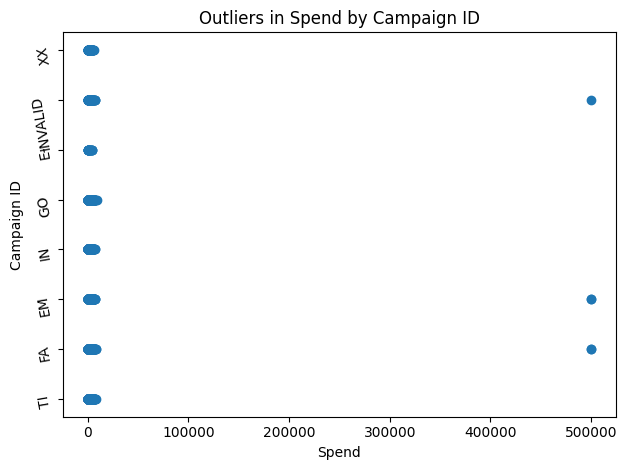

In [595]:
# Import the matplotlib.pyplot library for plotting.
import matplotlib.pyplot as plt

# Create a scatter plot to visualize the distribution of 'Spend' against 'Campaign_Tag'.
plt.scatter(df_unclean['Spend'],df_unclean['Campaign_Tag'])
# Label the x-axis as 'Spend'.
plt.xlabel('Spend')
# Label the y-axis as 'Campaign ID'.
plt.ylabel('Campaign ID')
# Set the title of the plot to clearly indicate what is being displayed.
plt.title('Outliers in Spend by Campaign ID')
# Set the y-axis ticks to unique campaign tags and rotate their labels for better readability.
plt.yticks(df_unclean['Campaign_Tag'].unique(),rotation=100)
# Adjust plot parameters for a tight layout, preventing labels from overlapping.
plt.tight_layout()
# Display the generated plot.
plt.show()

In [596]:
# Step8: Handling Outliers (WINSORIZING)
Q1=df_unclean['Spend'].quantile(0.25) # Calculate the first quartile (25th percentile) of 'Spend'.
Q3=df_unclean['Spend'].quantile(0.75) # Calculate the third quartile (75th percentile) of 'Spend'.
IQR=Q3-Q1 # Calculate the Interquartile Range (IQR).
upper_limit=Q3+(3*IQR) # Define the upper limit for outlier detection using 3*IQR rule.
# bound=Q3-(3*IQR) # This variable was defined but not used in the original logic, and 'lower_bound' was undefined.

outlier_mask=df_unclean['Spend']>upper_limit # Create a boolean mask for 'Spend' values exceeding the upper limit.
print(df_unclean.loc[outlier_mask,['Campaign_ID','Spend']]) # Display Campaign_ID and Spend for identified outliers before winsorization.

print("+"*30,"FIX APPLIED","+"*30) # Print a separator to indicate fix application.
# Apply Winsorization: replace upper outliers with the upper_limit
df_unclean.loc[outlier_mask,'Spend']=upper_limit # Winsorize: cap 'Spend' outliers at the calculated upper limit.
print(df_unclean.loc[outlier_mask,['Campaign_ID','Spend']]) # Display Campaign_ID and Spend for winsorized outliers.

     Campaign_ID      Spend
789    CMP-00790  500000.00
1443   CMP-01444    8921.51
1460   CMP-01461  500000.00
1718   CMP-01719  500000.00
1754   CMP-01755  500000.00
1781   CMP-01782  500000.00
++++++++++++++++++++++++++++++ FIX APPLIED ++++++++++++++++++++++++++++++
     Campaign_ID      Spend
789    CMP-00790  8603.5375
1443   CMP-01444  8603.5375
1460   CMP-01461  8603.5375
1718   CMP-01719  8603.5375
1754   CMP-01755  8603.5375
1781   CMP-01782  8603.5375


<Axes: xlabel='Spend', ylabel='Count'>

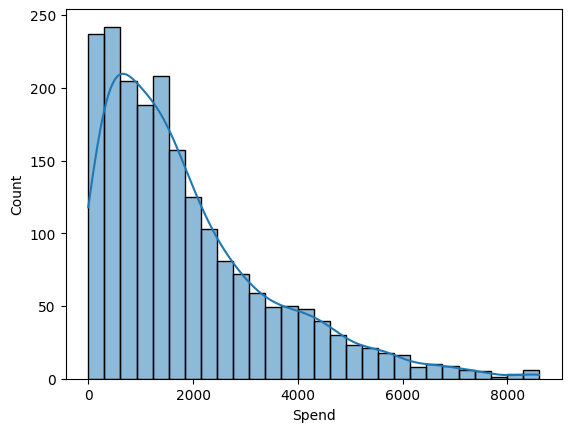

In [597]:
import seaborn as sns # Import seaborn for statistical data visualization
sns.histplot(df_unclean['Spend'], kde=True) # Create a histogram with a Kernel Density Estimate (KDE) for the 'Spend' column

In [598]:
print(df_unclean.loc[outlier_mask,'Spend']) # Display the 'Spend' values of the identified outliers after winsorization.

789     8603.5375
1443    8603.5375
1460    8603.5375
1718    8603.5375
1754    8603.5375
1781    8603.5375
Name: Spend, dtype: float64


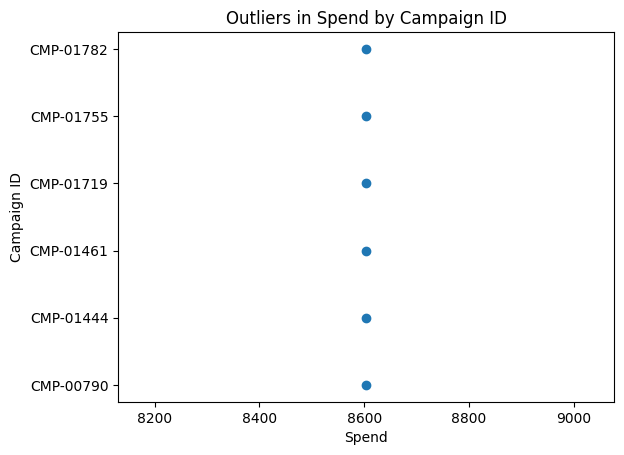

In [599]:
# Import the matplotlib.pyplot library for plotting.
import matplotlib.pyplot as plt
# Filter the original DataFrame to get only the rows identified as outliers based on the 'outlier_mask'.
outlier_data = df_unclean.loc[outlier_mask]
# Create a scatter plot to visualize the outliers.
# 'Spend' values are plotted on the x-axis and 'Campaign_ID' on the y-axis.
plt.scatter(outlier_data['Spend'],outlier_data['Campaign_ID'])
# Label the x-axis as 'Spend'.
plt.xlabel('Spend')
# Label the y-axis as 'Campaign ID'.
plt.ylabel('Campaign ID')
# Set the title of the plot to clearly indicate what is being displayed.
plt.title('Outliers in Spend by Campaign ID')
# Display the generated plot.
plt.show()

In [600]:
#Step9: String Parsing (Feature Extraction)
print("Extracting Seasons from the Campaign_Name column")
# The previous error occurred because 'df_seasons' (an array of unique campaign names)
# was incorrectly used as row labels for df_unclean, which has a numerical index.

# To extract the season from 'Campaign_Name', we can split the string.
# The regex r'Q\d_([^_]+)_' works as follows:
# - 'Q\d': Matches 'Q' followed by a single digit (e.g., 'Q1', 'Q4').
# - '_': Matches the underscore character.
# - '([^_]+)': This is the capturing group. It matches one or more characters that are NOT an underscore.
#              This effectively captures the season name (e.g., 'Summer', 'Launch', 'BlackFriday').
# - '_': Matches the final underscore character, ensuring the pattern matches the full season part.
df_unclean['Season']=df_unclean['Campaign_Name'].str.extract(r'Q\d_([^_]+)_')
print("+"*30,"FIX APPLIED","+"*30)
print(df_unclean[['Campaign_Name', 'Season']].head())
print("\nUnique Seasons extracted:")
print(df_unclean['Season'].unique())

Extracting Seasons from the Campaign_Name column
++++++++++++++++++++++++++++++ FIX APPLIED ++++++++++++++++++++++++++++++
              Campaign_Name       Season
0       Q4_Summer_CMP-00001       Summer
1       Q1_Launch_CMP-00002       Launch
2       Q3_Winter_CMP-00003       Winter
3  Q1_BlackFriday_CMP-00004  BlackFriday
4       Q2_Winter_CMP-00005       Winter

Unique Seasons extracted:
['Summer' 'Launch' 'Winter' 'BlackFriday']


All the cleaning is done **https://colab.research.google.com/**